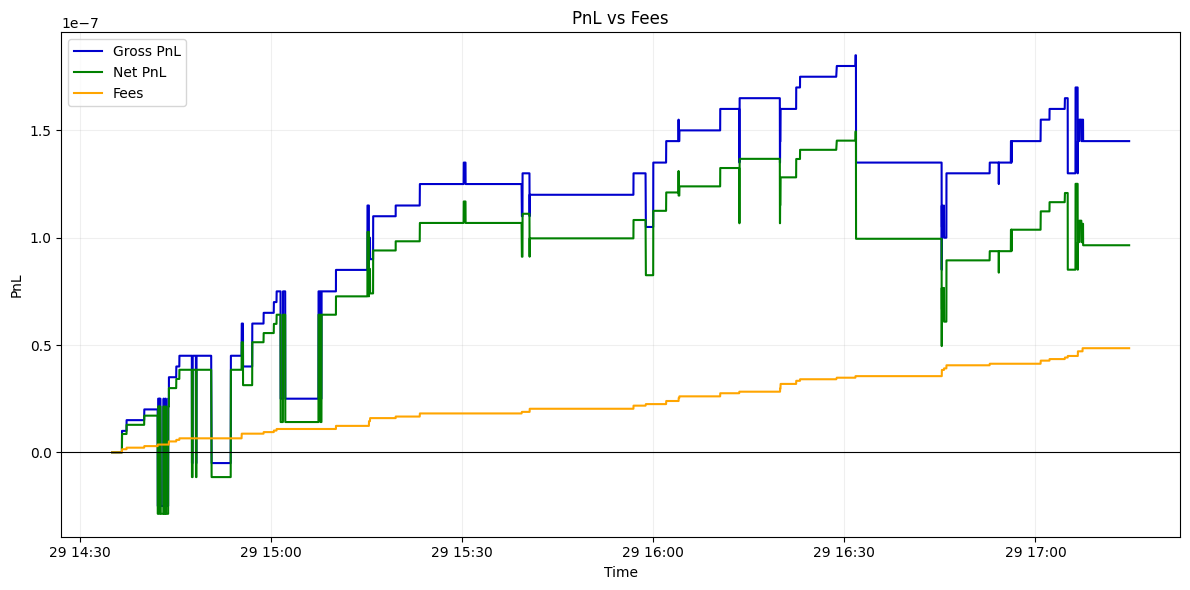

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder_path = r"D:\OneDrive\Trading\Market Making\data\runs\run_20260829_063459"

snapshots = pd.read_parquet(os.path.join(folder_path, "snapshots.parquet"))
snapshots["ts"] = pd.to_datetime(snapshots["ts"], unit="ms", utc=True).dt.tz_convert("Asia/Singapore")

snapshots = snapshots.sort_values("ts")
snapshots["gross_pnl"] = snapshots["unrealized_pnl"] + snapshots["realized_pnl"]

plt.figure(figsize=(12, 6))

plt.plot(snapshots["ts"], snapshots["gross_pnl"], label="Gross PnL", color="mediumblue")
plt.plot(snapshots["ts"], snapshots["total_pnl"], label="Net PnL", color="green")
plt.plot(snapshots["ts"], snapshots["fees_paid"], label="Fees", color="orange")

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("PnL")
plt.title("PnL vs Fees")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()